In [96]:
import geopandas as gpd
import matplotlib.pyplot as plt
from cartopy import crs as ccrs
from geodatasets import get_path
import pandas as pd
from datetime import datetime, timedelta
import numpy as np


In [93]:
#Date function for title -> returns a string that states the start date - end date. 
#The start date is defined through the input variable (xdays_in_the_past) which is the number of days that will be subtracted from today's date.
#Example: xdays_in_the_past=10 and today's date is the 15.05.2026 -> output: 5. May 2026 - 15. May 2026

def datefunction(xdays_in_the_past):
    todays_date = datetime.today()
    start_date = ((todays_date - timedelta(days=xdays_in_the_past)).date()).strftime("%d. %B %Y")
    end_date = (todays_date.date()).strftime("%d. %B %Y")
    date_span = (f"{start_date} - {end_date}")
    
    return date_span

World Hexbinmap with FRP as a colour variable:

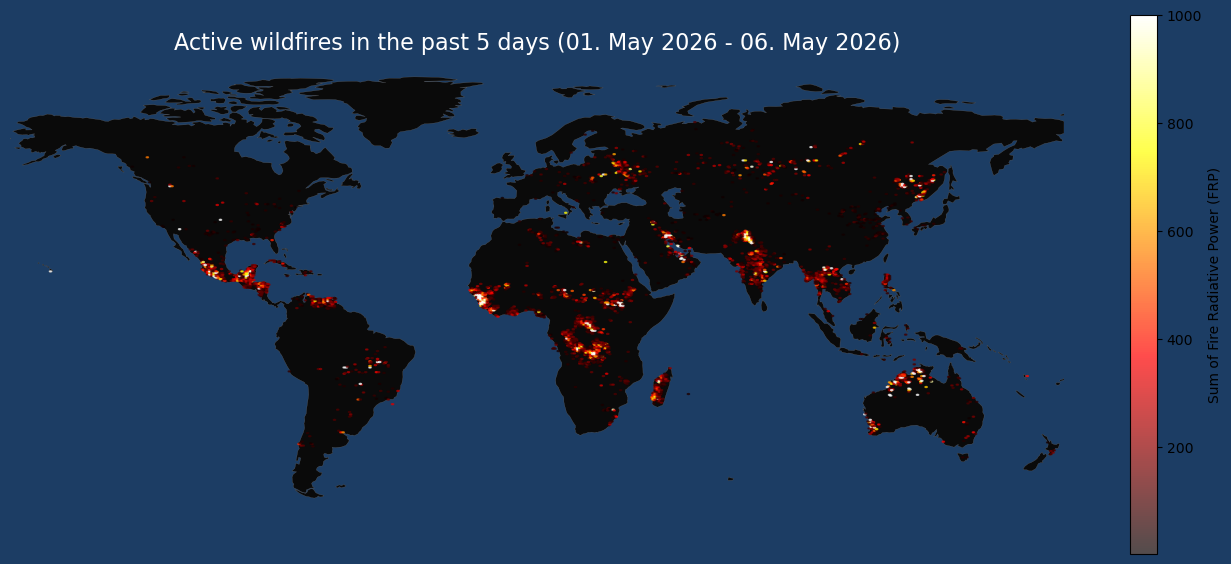

In [112]:
# Load world basemap from "geodatasets"
path = get_path("naturalearth.land")
world = gpd.read_file(path)

# My API key for the last five days of data from the VIIRS S-NPP satellite sensor
API_KEY = "875c5f8321acb83297f0d59448343c67"

url = f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/{API_KEY}/VIIRS_SNPP_NRT/world/5"

FIRMS_df = pd.read_csv(url)

# Convert fire data to georeferenced points 
fires_df = gpd.GeoDataFrame(FIRMS_df, geometry=gpd.points_from_xy(FIRMS_df["longitude"], FIRMS_df["latitude"]))

# Worldmap with darkblue background
fig, ax = plt.subplots(figsize=(17, 7))
fig.patch.set_facecolor("#1c3d64")

world.plot(
    ax=ax,
    color="#0a0a0a",
    edgecolor="#666464",
    linewidth=0.2
)
#
hexbin_map = ax.hexbin(
    FIRMS_df["longitude"],
    FIRMS_df["latitude"],
    C=FIRMS_df["frp"],
    reduce_C_function=sum,
    gridsize=500,
    vmin=1,
    vmax=1000,
    cmap="hot",
    mincnt=10,
    alpha=0.7
)

fig.colorbar(hexbin_map, ax=ax, label="Sum of Fire Radiative Power (FRP)")

# Map cosmetics (title and removing lon,lat)
ax.set_title(f"Active wildfires in the past 5 days ({datefunction(5)})", fontsize=16, color="white")
ax.set_axis_off()

#clipping map for better visibility
ax.set_ylim(-60, 90)
ax.set_xlim(-169, 180)
plt.show()


World map with Pointdata and frp as a colour variable:

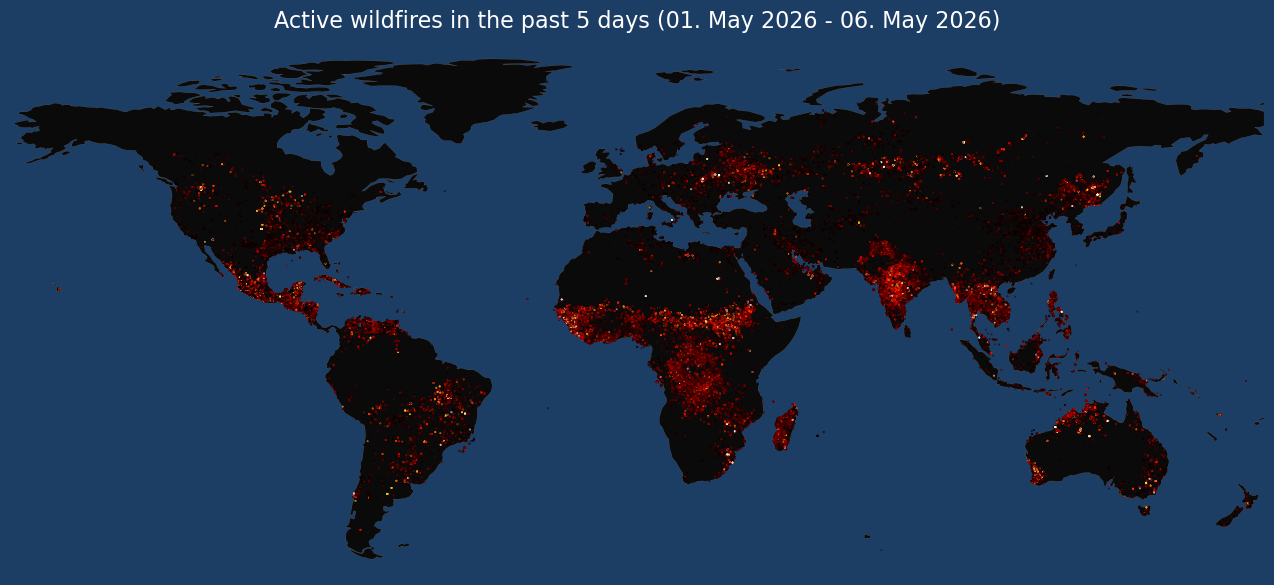

In [113]:
# Load world basemap from "geodatasets"
path = get_path("naturalearth.land")
world = gpd.read_file(path)

# My API key for the last five days of data from the VIIRS S-NPP satellite sensor
API_KEY = "875c5f8321acb83297f0d59448343c67"

url = f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/{API_KEY}/VIIRS_SNPP_NRT/world/5"

FIRMS_df = pd.read_csv(url)

# Convert fire data to georeferenced points 
fires_df = gpd.GeoDataFrame(FIRMS_df, geometry=gpd.points_from_xy(FIRMS_df["longitude"], FIRMS_df["latitude"]))

# Worldmap with dark blue background
fig, ax = plt.subplots(figsize=(17, 7))
fig.patch.set_facecolor("#1c3d64")

world.plot(
    ax=ax,
    color="#0a0a0a",
    edgecolor="#666464",
    linewidth=0.2
)

#Plotting the firepoints, vmin/max is the span of frp(Mw) that the Points can be in. The vmax is reduced to create a more readable map
fires_df.plot(
    ax=ax,
    column="frp",
    cmap="hot",
    vmin=1,
    vmax=40,
    markersize=0.1,
    alpha=0.9
)


# Map cosmetics (title and removing lon,lat)
ax.set_title(f"Active wildfires in the past 5 days ({datefunction(5)})", fontsize=16, color="white")
ax.set_axis_off()

#clipping map for better visibility
ax.set_ylim(-60, 90)
ax.set_xlim(-169, 180)
plt.show()
